In [1]:
!git clone https://github.com/michaelhunter12/linear_models.git

Cloning into 'linear_models'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 72 (delta 21), reused 12 (delta 12), pack-reused 38 (from 1)
Receiving objects: 100% (72/72), 3.73 MiB | 12.65 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [3]:
Q1 = pd.read_csv('linear_models/data/Q1_clean.csv')
Q1.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [4]:
avg_neighbourhood = Q1.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
display(avg_neighbourhood)

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhattan is the most expensive on average.

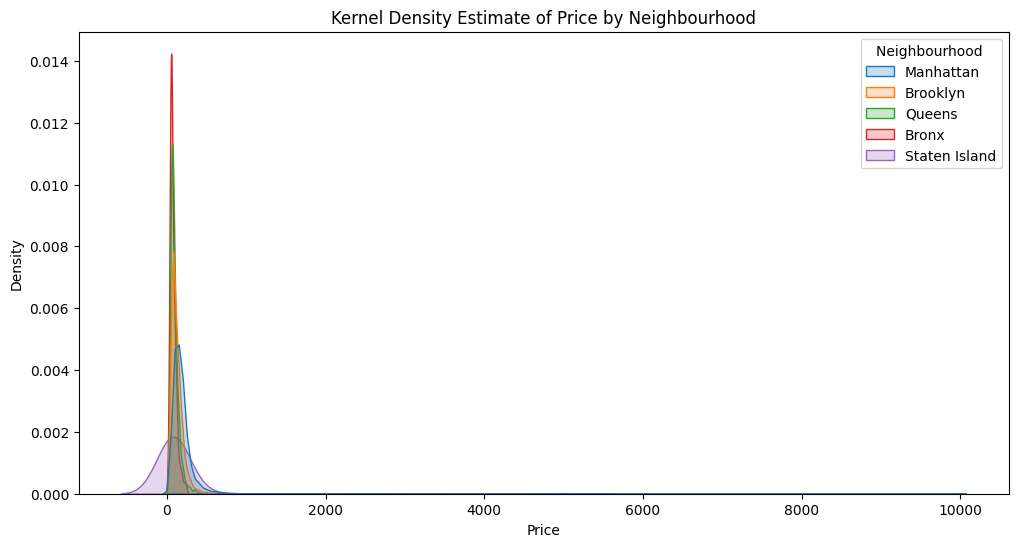

In [5]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=Q1, x='Price', hue='Neighbourhood ', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Price by Neighbourhood')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

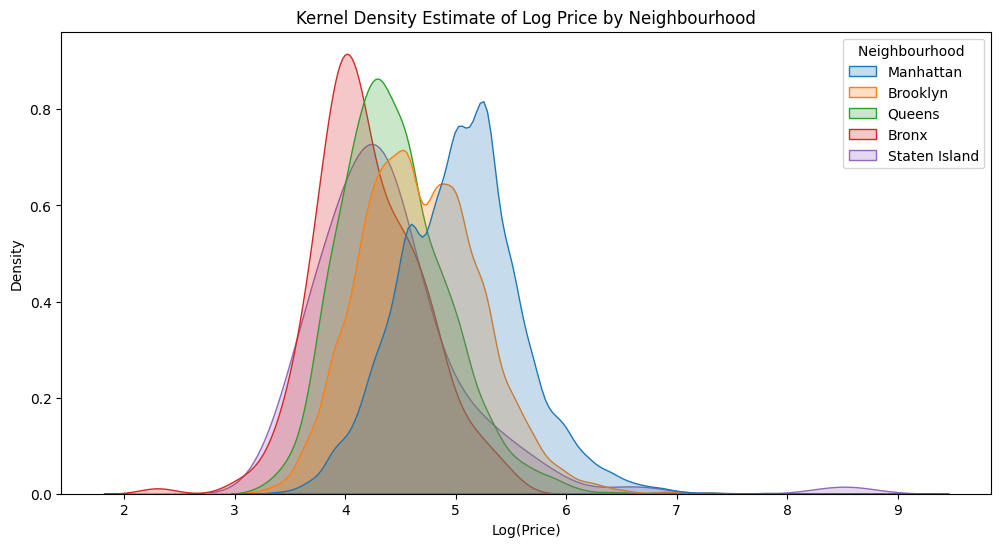

In [6]:
Q1['log_Price'] = np.log(Q1['Price'])

plt.figure(figsize=(12, 6))
sns.kdeplot(data=Q1, x='log_Price', hue='Neighbourhood ', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Log Price by Neighbourhood')
plt.xlabel('Log(Price)')
plt.ylabel('Density')
plt.show()

In [7]:
X = Q1[['Neighbourhood ']]
y = Q1['Price']

binarizer = LabelBinarizer()
X_encoded = binarizer.fit_transform(X['Neighbourhood '])

feature_names = [f'{c}' for c in binarizer.classes_]
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)

model = LinearRegression(fit_intercept=False)
model.fit(X_encoded_df, y)

coefficients_df = pd.DataFrame({'Neighbourhood': feature_names, 'Coefficient/Price': model.coef_})
display(coefficients_df)

,Neighbourhood,Coefficient/Price
0,Bronx,75.276498
1,Brooklyn,127.747378
2,Manhattan,183.664286
3,Queens,96.857233
4,Staten Island,146.166667


The pattern is that the coeffiecient perfectaly matches the average price. For a regresion of a continuous variable on one categorical, the coffiecient/price for the regression are just the mean values for the neighborhood price.

In [9]:
from sklearn.linear_model import LinearRegression
import pandas as pd

X = Q1[['Neighbourhood ']]
y = Q1['Price']

X_encoded_with_intercept = pd.get_dummies(X, columns=['Neighbourhood '], drop_first=True, dtype=int)

model_with_intercept = LinearRegression(fit_intercept=True)
model_with_intercept.fit(X_encoded_with_intercept, y)

print(f"Intercept: {model_with_intercept.intercept_:.2f}")
coefficients_with_intercept_df = pd.DataFrame({
    'Neighbourhood_Category': X_encoded_with_intercept.columns,
    'Coefficient': model_with_intercept.coef_
})
display(coefficients_with_intercept_df)

Intercept: 75.28


,Neighbourhood_Category,Coefficient
0,Neighbourhood _Brooklyn,52.470881
1,Neighbourhood _Manhattan,108.387789
2,Neighbourhood _Queens,21.580735
3,Neighbourhood _Staten Island,70.890169


Handling Dummy Variables: drop one of the one-hot encoded dummy variables to avoid multicolinearity. The Bronx neighborhood needed to be dropped to become the refernce group.

Intercept: The intercept is the average price of properties in the Bronx, which is serving as the reference group.

Coeffcients: The coefficient is the difference between the predicted price of a neigborhood vs the Bronx (reference category)

Get the coeffieicnets from part 2: Add the intercept to the coefficient from this part.



In [27]:
X = Q1[['Review Scores Rating', 'Neighbourhood ']].copy()
y = Q1['Price']

X_encoded = pd.get_dummies(X, columns=['Neighbourhood '], drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared on test set: {r2:.2f}")
print(f"RMSE on test set: {rmse:.2f}")

review_scores_coeff = model.coef_[X_encoded.columns.get_loc('Review Scores Rating')]
print(f"Coefficient on 'Review Scores Rating': {review_scores_coeff:.2f}")

intercept = model.intercept_
coefficients = pd.Series(model.coef_, index=X_encoded.columns)


neighbourhood_prices = {}
neighbourhood_prices['Bronx'] = intercept

for col, coeff in coefficients.items():
    if 'Neighbourhood' in col:
        neighbourhood_name = col.replace('Neighbourhood _', '')
        neighbourhood_prices[neighbourhood_name] = intercept + coeff

most_expensive_neighbourhood = max(neighbourhood_prices, key=neighbourhood_prices.get)
most_expensive_price = neighbourhood_prices[most_expensive_neighbourhood]

print(f"The most expensive kind of property (by Neighbourhood) is in {most_expensive_neighbourhood} with an estimated base price of {most_expensive_price:.2f}")

#Help from GeminiAI

R-squared on test set: 0.05
RMSE on test set: 140.92
Coefficient on 'Review Scores Rating': 1.21
The most expensive kind of property (by Neighbourhood) is in Manhattan with an estimated base price of 72.26


In [26]:
# Prepare data for regression, including 'Property Type'
X = Q1[['Review Scores Rating', 'Neighbourhood ', 'Property Type']].copy()
y = Q1['Price']

# One-hot encode 'Neighbourhood ' and 'Property Type' columns, dropping the first category to avoid multicollinearity
X_encoded = pd.get_dummies(X, columns=['Neighbourhood ', 'Property Type'], drop_first=True, dtype=int)

# Split the data into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate R-squared and RMSE on the test set
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared on test set: {r2:.2f}")
print(f"RMSE on test set: {rmse:.2f}")

# Get the coefficient for 'Review Scores Rating'
review_scores_coeff = model.coef_[X_encoded.columns.get_loc('Review Scores Rating')]
print(f"Coefficient on 'Review Scores Rating': {review_scores_coeff:.2f}")

# Identify the most expensive kind of property based on coefficients
# The intercept represents the base price (for the dropped Neighbourhood and Property Type)
intercept = model.intercept_
coefficients = pd.Series(model.coef_, index=X_encoded.columns)

# To find the most expensive 'kind of property', we need to consider both Neighbourhood and Property Type.
# We will calculate the 'base price' for each combination of the reference categories for Neighbourhood and Property Type,
# and then add the relevant coefficients.

# First, identify the reference categories
all_neighbourhoods = Q1['Neighbourhood '].unique()
all_property_types = Q1['Property Type'].unique()

# Get the alphabetically first (likely dropped) for reference
ref_neighbourhood = sorted(all_neighbourhoods)[0]
ref_property_type = sorted(all_property_types)[0]

max_predicted_price = -np.inf
most_expensive_combination = ""

# Create a dummy row for prediction for each combination, assuming Review Scores Rating is at its mean
mean_review_score = X['Review Scores Rating'].mean()

for neighbourhood in all_neighbourhoods:
    for prop_type in all_property_types:
        prediction_row_data = {'Review Scores Rating': float(mean_review_score)}

        for col in X_encoded.columns:
            if 'Neighbourhood_' in col:
                neighbourhood_name_from_col = col.replace('Neighbourhood _', '')
                if neighbourhood_name_from_col == neighbourhood and neighbourhood != ref_neighbourhood:
                    prediction_row_data[col] = 1
                else:
                    prediction_row_data[col] = 0
            elif 'Property Type_' in col:
                property_type_name_from_col = col.replace('Property Type_', '')
                if property_type_name_from_col == prop_type and prop_type != ref_property_type:
                    prediction_row_data[col] = 1
                else:
                    prediction_row_data[col] = 0
            elif col not in prediction_row_data: # For other columns not handled yet (like Review Scores Rating)
                 prediction_row_data[col] = 0

        # Ensure all columns are present, fill missing with 0
        final_prediction_row = pd.Series(prediction_row_data).reindex(X_encoded.columns, fill_value=0)
        temp_df = pd.DataFrame([final_prediction_row])

        # Predict price for this combination
        predicted_price = model.predict(temp_df)[0]

        if predicted_price > max_predicted_price:
            max_predicted_price = predicted_price
            most_expensive_combination = f"{prop_type} in {neighbourhood}"

print(f"The most expensive kind of property you can rent is a {most_expensive_combination} with an estimated average price of {max_predicted_price:.2f}")

#Help from GeminiAI

R-squared on test set: 0.05
RMSE on test set: 140.30
Coefficient on 'Review Scores Rating': 1.20
The most expensive kind of property you can rent is a Bungalow in Manhattan with an estimated average price of 145.16


Part 4 coefficient: 1.21. Expected change in price for a one-unit increase in Review Score Rating (neighborhood held constant).

Part 5 coefficient: 1.20. Expected change in price for a one-unit increase in Review Score Rating (neighborhood and property type held constant).

The slight decrease shows that adding property type to the model helps give a better estimate of the review score's effect on price. The coefficient in part 4 has some influence from property type, which muddies the relationship of review score and price.



**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [28]:
cars = pd.read_csv('linear_models/data/cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [29]:
cars.describe()

,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price
count,976.000000,976.000000,976.000000,976.000000,9.760000e+02
mean,488.500000,2016.963115,41571.195697,5.095287,7.410195e+05
std,281.891232,2.818742,24390.995134,0.446224,3.673234e+05
min,1.000000,2011.000000,1117.000000,4.000000,1.880000e+05
25%,244.750000,2015.000000,22676.750000,5.000000,4.757500e+05
50%,488.500000,2017.000000,37570.500000,5.000000,6.665000e+05
75%,732.250000,2019.000000,57421.250000,5.000000,8.830000e+05
max,976.000000,2022.000000,99495.000000,8.000000,2.941000e+06


In [30]:
cars.shape

(976, 12)

In [44]:
cars_new = cars.drop('Unnamed: 0', axis=1)
display(cars_new.head())

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


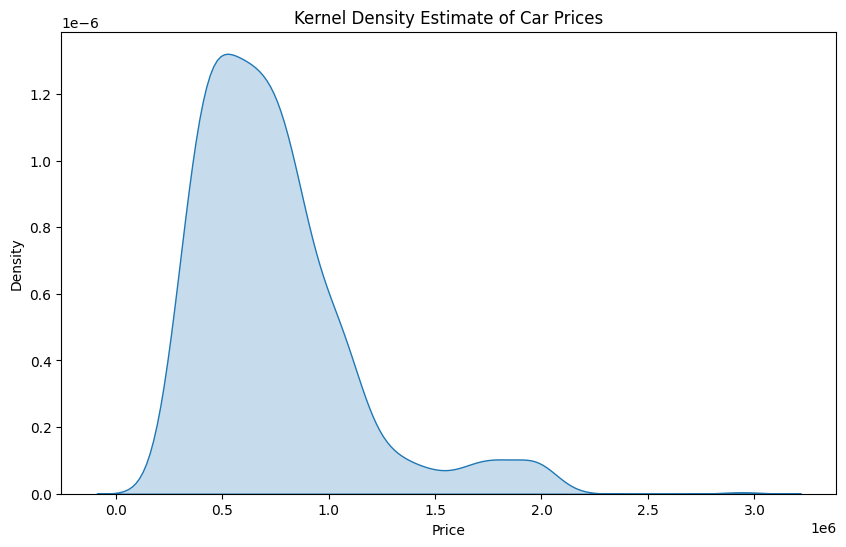

In [54]:
display(cars_new['Price'].describe())

plt.figure(figsize=(10, 6))
sns.kdeplot(cars_new['Price'], fill=True)
plt.title('Kernel Density Estimate of Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
MG Motors,35.0,1.869457e+06,1.216611e+05,1589000.0,1786500.0,1848000.0,1978000.0,2019000.0
Kia,8.0,1.614750e+06,1.190567e+05,1369000.0,1579000.0,1628500.0,1705750.0,1741000.0
Jeep,4.0,1.499500e+06,1.525134e+05,1290000.0,1447500.0,1529500.0,1581500.0,1649000.0
Skoda,5.0,1.136000e+06,1.070175e+06,436000.0,466000.0,538000.0,1299000.0,2941000.0
Mahindra,18.0,1.100167e+06,1.755493e+05,796000.0,1037000.0,1094500.0,1157000.0,1465000.0
Tata,23.0,1.055217e+06,5.578305e+05,188000.0,779500.0,869000.0,1552000.0,2100000.0
Nissan,4.0,8.842500e+05,2.895599e+05,475000.0,782500.0,978000.0,1079750.0,1106000.0
Toyota,50.0,8.003400e+05,2.466900e+05,368000.0,526250.0,894000.0,1023000.0,1092000.0
Honda,73.0,7.989726e+05,2.665091e+05,316000.0,581000.0,785000.0,915000.0,1537000.0


/tmp/ipykernel_12288/1702630795.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')


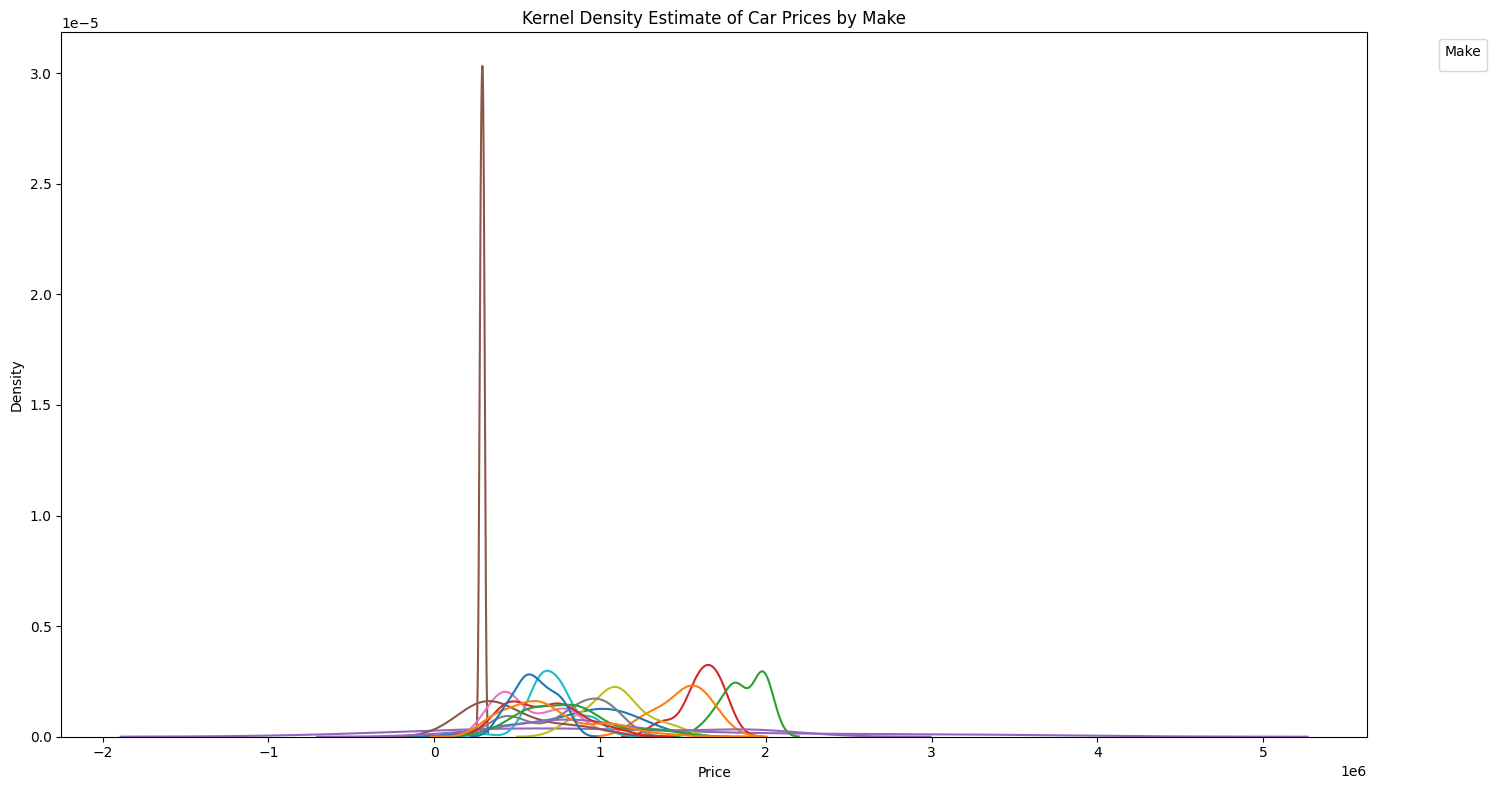

In [55]:

avg_price_by_make = cars_new.groupby('Make')['Price'].describe().sort_values(by='mean', ascending=False)
display(avg_price_by_make)

plt.figure(figsize=(15, 8))
sns.kdeplot(data=cars_new, x='Price', hue='Make', fill=False, common_norm=False, palette='tab10')
plt.title('Kernel Density Estimate of Car Prices by Make')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Prices are suprisingly expensive all around the board, as the average for all cars is 750000, which is very high. MG Motors, Kia and Jeep have the highest prices.

In [57]:
y = cars_new['Price']
X = cars_new.drop('Price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model 1: Regression on Numeric Variables Alone

In [62]:
# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=np.number).columns

# Prepare data for the first model (numeric variables only)
X_train_numeric = X_train[numeric_cols]
X_test_numeric = X_test[numeric_cols]

# Initialize and train the linear regression model
model_numeric = LinearRegression()
model_numeric.fit(X_train_numeric, y_train)

# Make predictions on training and test sets
y_train_pred_numeric = model_numeric.predict(X_train_numeric)
y_test_pred_numeric = model_numeric.predict(X_test_numeric)

# Calculate R-squared and RMSE for training set
r2_train_numeric = r2_score(y_train, y_train_pred_numeric)
rmse_train_numeric = np.sqrt(mean_squared_error(y_train, y_train_pred_numeric))

# Calculate R-squared and RMSE for test set
r2_test_numeric = r2_score(y_test, y_test_pred_numeric)
rmse_test_numeric = np.sqrt(mean_squared_error(y_test, y_test_pred_numeric))

print(f"\nModel 1 (Numeric Variables Only) - Training R-squared: {r2_train_numeric:.2f}")
print(f"Model 1 (Numeric Variables Only) - Training RMSE: {rmse_train_numeric:.2f}")
print(f"Model 1 (Numeric Variables Only) - Test R-squared: {r2_test_numeric:.2f}")
print(f"Model 1 (Numeric Variables Only) - Test RMSE: {rmse_test_numeric:.2f}")

#Help from GeminiAI


Model 1 (Numeric Variables Only) - Training R-squared: 0.31
Model 1 (Numeric Variables Only) - Training RMSE: 309338.37
Model 1 (Numeric Variables Only) - Test R-squared: 0.29
Model 1 (Numeric Variables Only) - Test RMSE: 284546.95


## Model 2: Regression on One-Hot Encoded Categorical Variables Alone

In [63]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# One-hot encode categorical variables for training and test sets
X_train_categorical = pd.get_dummies(X_train[categorical_cols], drop_first=True, dtype=int)
X_test_categorical = pd.get_dummies(X_test[categorical_cols], drop_first=True, dtype=int)

# Align columns - this is crucial to ensure both train and test sets have the same columns after one-hot encoding
# Fill missing columns (due to categories present in one set but not the other) with 0
X_train_categorical, X_test_categorical = X_train_categorical.align(X_test_categorical, join='outer', axis=1, fill_value=0)

# Initialize and train the linear regression model
model_categorical = LinearRegression()
model_categorical.fit(X_train_categorical, y_train)

# Make predictions on test set
y_test_pred_categorical = model_categorical.predict(X_test_categorical)

# Calculate R-squared and RMSE for test set
r2_test_categorical = r2_score(y_test, y_test_pred_categorical)
rmse_test_categorical = np.sqrt(mean_squared_error(y_test, y_test_pred_categorical))

print(f"\nModel 2 (Categorical Variables Only) - Test R-squared: {r2_test_categorical:.2f}")
print(f"Model 2 (Categorical Variables Only) - Test RMSE: {rmse_test_categorical:.2f}")

#Help from GeminiAI


Model 2 (Categorical Variables Only) - Test R-squared: 0.71
Model 2 (Categorical Variables Only) - Test RMSE: 182791.11


## Comparison of Model 1 and Model 2 (on Test Set)

In [64]:
print(f"Model 1 (Numeric Only) Test R-squared: {r2_test_numeric:.2f}")
print(f"Model 1 (Numeric Only) Test RMSE: {rmse_test_numeric:.2f}")
print(f"\nModel 2 (Categorical Only) Test R-squared: {r2_test_categorical:.2f}")
print(f"Model 2 (Categorical Only) Test RMSE: {rmse_test_categorical:.2f}")

if r2_test_numeric > r2_test_categorical:
    print("\nModel 1 (Numeric Variables Only) performs better on the test set (higher R-squared).")
elif r2_test_categorical > r2_test_numeric:
    print("\nModel 2 (Categorical Variables Only) performs better on the test set (higher R-squared).")
else:
    print("\nBoth models perform similarly on the test set.")

#Help from GeminiAI

Model 1 (Numeric Only) Test R-squared: 0.29
Model 1 (Numeric Only) Test RMSE: 284546.95

Model 2 (Categorical Only) Test R-squared: 0.71
Model 2 (Categorical Only) Test RMSE: 182791.11

Model 2 (Categorical Variables Only) performs better on the test set (higher R-squared).


## Model 3: Combined Numeric and Categorical Variables

In [66]:
# Combine numeric and one-hot encoded categorical features
X_train_combined = pd.concat([X_train_numeric, X_train_categorical], axis=1)
X_test_combined = pd.concat([X_test_numeric, X_test_categorical], axis=1)

# Initialize and train the linear regression model
model_combined = LinearRegression()
model_combined.fit(X_train_combined, y_train)

# Make predictions on test set
y_test_pred_combined = model_combined.predict(X_test_combined)

# Calculate R-squared and RMSE for test set
r2_test_combined = r2_score(y_test, y_test_pred_combined)
rmse_test_combined = np.sqrt(mean_squared_error(y_test, y_test_pred_combined))

print(f"\nModel 3 (Combined Variables) - Test R-squared: {r2_test_combined:.2f}")
print(f"Model 3 (Combined Variables) - Test RMSE: {rmse_test_combined:.2f}")

print("\nComparison with previous best model on test set:")
current_best_r2 = max(r2_test_numeric, r2_test_categorical)

if r2_test_combined > current_best_r2:
    r2_improvement = r2_test_combined - current_best_r2
    print(f"The joint model performs better by an R-squared of {r2_improvement:.2f}.")
elif r2_test_combined < current_best_r2:
    r2_difference = current_best_r2 - r2_test_combined
    print(f"The joint model performs worse by an R-squared of {r2_difference:.2f}.")
else:
    print("The joint model performs similarly to the previous best model.")

#Help from GeminiAI


Model 3 (Combined Variables) - Test R-squared: 0.82
Model 3 (Combined Variables) - Test RMSE: 143575.20

Comparison with previous best model on test set:
The joint model performs better by an R-squared of 0.11.


In [69]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Identify numeric columns from the original X_train (before one-hot encoding categorical)
numeric_cols_original = X_train.select_dtypes(include=np.number).columns

# Prepare numeric data for polynomial expansion
X_train_numeric_for_poly = X_train[numeric_cols_original]
X_test_numeric_for_poly = X_test[numeric_cols_original]

# Define the categorical features that were one-hot encoded earlier
categorical_cols = X_train.select_dtypes(include='object').columns
X_train_categorical = pd.get_dummies(X_train[categorical_cols], drop_first=True, dtype=int)
X_test_categorical = pd.get_dummies(X_test[categorical_cols], drop_first=True, dtype=int)

# Align columns for categorical data, as done previously
X_train_categorical, X_test_categorical = X_train_categorical.align(X_test_categorical, join='outer', axis=1, fill_value=0)


results = []

for degree in range(1, 4):
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    # Fit and transform polynomial features on training data
    X_train_poly = poly.fit_transform(X_train_numeric_for_poly)
    X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out(X_train_numeric_for_poly.columns), index=X_train.index)

    # Transform test data
    X_test_poly = poly.transform(X_test_numeric_for_poly)
    X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly.get_feature_names_out(X_test_numeric_for_poly.columns), index=X_test.index)

    # Combine polynomial features with categorical features
    X_train_combined_poly = pd.concat([X_train_poly_df, X_train_categorical], axis=1)
    X_test_combined_poly = pd.concat([X_test_poly_df, X_test_categorical], axis=1)

    # Initialize and train the linear regression model
    model_poly = LinearRegression()
    model_poly.fit(X_train_combined_poly, y_train)

    # Make predictions on training and test sets
    y_train_pred_poly = model_poly.predict(X_train_combined_poly)
    y_test_pred_poly = model_poly.predict(X_test_combined_poly)

    # Calculate R-squared and RMSE for training set
    r2_train_poly = r2_score(y_train, y_train_pred_poly)
    rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))

    # Calculate R-squared and RMSE for test set
    r2_test_poly = r2_score(y_test, y_test_pred_poly)
    rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))

    results.append({
        'degree': degree,
        'R2_train': r2_train_poly,
        'RMSE_train': rmse_train_poly,
        'R2_test': r2_test_poly,
        'RMSE_test': rmse_test_poly,
        'model': model_poly
    })

    print(f"\n--- Degree {degree} ---")
    print(f"Training R-squared: {r2_train_poly:.2f}")
    print(f"Training RMSE: {rmse_train_poly:.2f}")
    print(f"Test R-squared: {r2_test_poly:.2f}")
    print(f"Test RMSE: {rmse_test_poly:.2f}")

# Find the best model based on test R-squared
best_model_poly = max(results, key=lambda x: x['R2_test'])

print(f"\nBest model with expanded features (Degree {best_model_poly['degree']}):")
print(f"Test R-squared: {best_model_poly['R2_test']:.2f}")
print(f"Test RMSE: {best_model_poly['RMSE_test']:.2f}")

# Compare with Model 3 from part 4
r2_model3 = r2_test_combined # From previous cell
rmse_model3 = rmse_test_combined # From previous cell

print(f"\nComparison with best model from Part 4 (Model 3):")
print(f"Model 3 R-squared: {r2_model3:.2f}")
print(f"Model 3 RMSE: {rmse_model3:.2f}")

if best_model_poly['R2_test'] > r2_model3:
    print(f"The best polynomial model (Degree {best_model_poly['degree']}) performs better than Model 3 by R-squared difference of {(best_model_poly['R2_test'] - r2_model3):.2f}.")
else:
    print(f"The best polynomial model (Degree {best_model_poly['degree']}) performs worse than Model 3 by R-squared difference of {(r2_model3 - best_model_poly['R2_test']):.2f}.")

# Check for negative R-squared on test set
negative_r2_degrees = [r['degree'] for r in results if r['R2_test'] < 0]
if negative_r2_degrees:
    print(f"\nR-squared went negative on the test set for degrees: {negative_r2_degrees}")
else:
    print("\nR-squared did not go negative on the test set for the tested degrees.")

#All done by GeminiAI


--- Degree 1 ---
Training R-squared: 0.86
Training RMSE: 142114.26
Test R-squared: 0.82
Test RMSE: 143575.20

--- Degree 2 ---
Training R-squared: 0.86
Training RMSE: 139717.82
Test R-squared: 0.82
Test RMSE: 142716.45

--- Degree 3 ---
Training R-squared: 0.34
Training RMSE: 303385.03
Test R-squared: 0.31
Test RMSE: 281003.61

Best model with expanded features (Degree 2):
Test R-squared: 0.82
Test RMSE: 142716.45

Comparison with best model from Part 4 (Model 3):
Model 3 R-squared: 0.82
Model 3 RMSE: 143575.20
The best polynomial model (Degree 2) performs better than Model 3 by R-squared difference of 0.00.

R-squared did not go negative on the test set for the tested degrees.


## Q3 Part 6: Model Evaluation and Residual Analysis

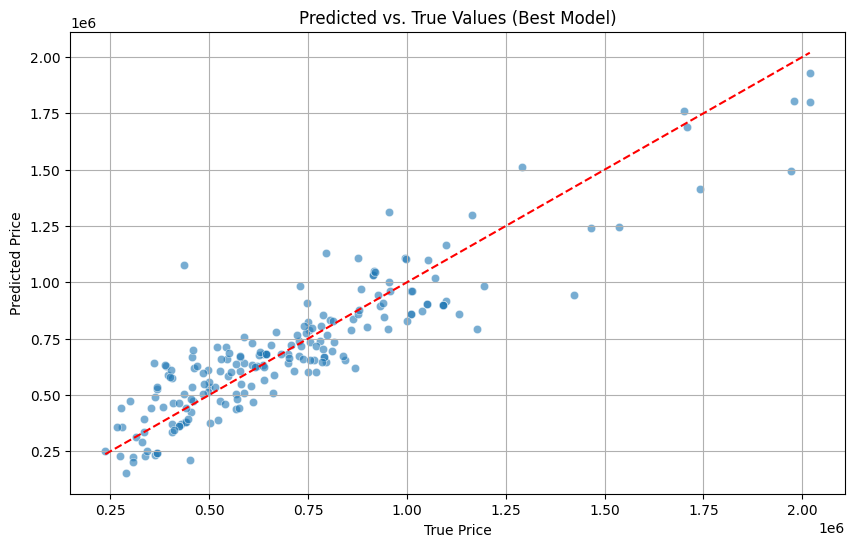

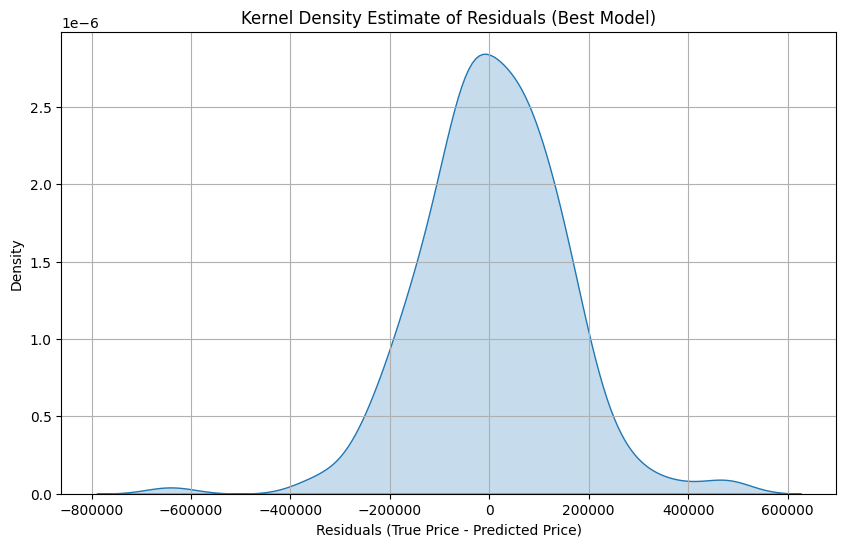

Best Model R-squared on Test Set: 0.82
Best Model RMSE on Test Set: 142716.45


In [75]:
# Reconstruct X_test data for the best polynomial degree
best_degree = best_model_poly['degree']
poly = PolynomialFeatures(degree=best_degree, include_bias=False)

# Ensure X_train_numeric_for_poly is available (from previous cells)
# Identify numeric columns from the original X_train (before one-hot encoding categorical)
numeric_cols_original = X_train.select_dtypes(include=np.number).columns
X_train_numeric_for_poly = X_train[numeric_cols_original]
X_test_numeric_for_poly = X_test[numeric_cols_original]

# Fit the PolynomialFeatures transformer on the training data
poly.fit(X_train_numeric_for_poly)

X_test_poly = poly.transform(X_test_numeric_for_poly)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly.get_feature_names_out(X_test_numeric_for_poly.columns), index=X_test.index)

# Ensure X_test_categorical is available (from previous cells)
categorical_cols = X_train.select_dtypes(include='object').columns
X_train_categorical = pd.get_dummies(X_train[categorical_cols], drop_first=True, dtype=int)
X_test_categorical = pd.get_dummies(X_test[categorical_cols], drop_first=True, dtype=int)
X_train_categorical, X_test_categorical = X_train_categorical.align(X_test_categorical, join='outer', axis=1, fill_value=0)

X_test_combined_for_best_poly = pd.concat([X_test_poly_df, X_test_categorical], axis=1)

# Get predictions from the best model
y_pred_best_model = best_model_poly['model'].predict(X_test_combined_for_best_poly)

# Plot Predicted vs. True Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_model, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line
plt.title('Predicted vs. True Values (Best Model)')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

# Compute Residuals
residuals = y_test - y_pred_best_model

# Create a Kernel Density Plot of Residuals
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals, fill=True)
plt.title('Kernel Density Estimate of Residuals (Best Model)')
plt.xlabel('Residuals (True Price - Predicted Price)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

print(f"Best Model R-squared on Test Set: {best_model_poly['R2_test']:.2f}")
print(f"Best Model RMSE on Test Set: {best_model_poly['RMSE_test']:.2f}")

#GeminiAI

Yes, the residuals look bell shaped and centered around zero

Strengths: The high R-squared values shows that the variance in the price is well explained. The predicted vs true values do not perfectally fall on the diagonal, but the close relationship shows that the model is making relatively accurate/reasonable predictions. As previously mentoned, the residuals represent a bell-shaped centered around zero, indicating that there is a normal distribution of error.

Weaknesses: Because the predicted vs true value points do not fall exactly on the diagonal, it indicates that there is still some unexplained variance in the model. Outliers can create instances where the model has a hard time predicting values.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

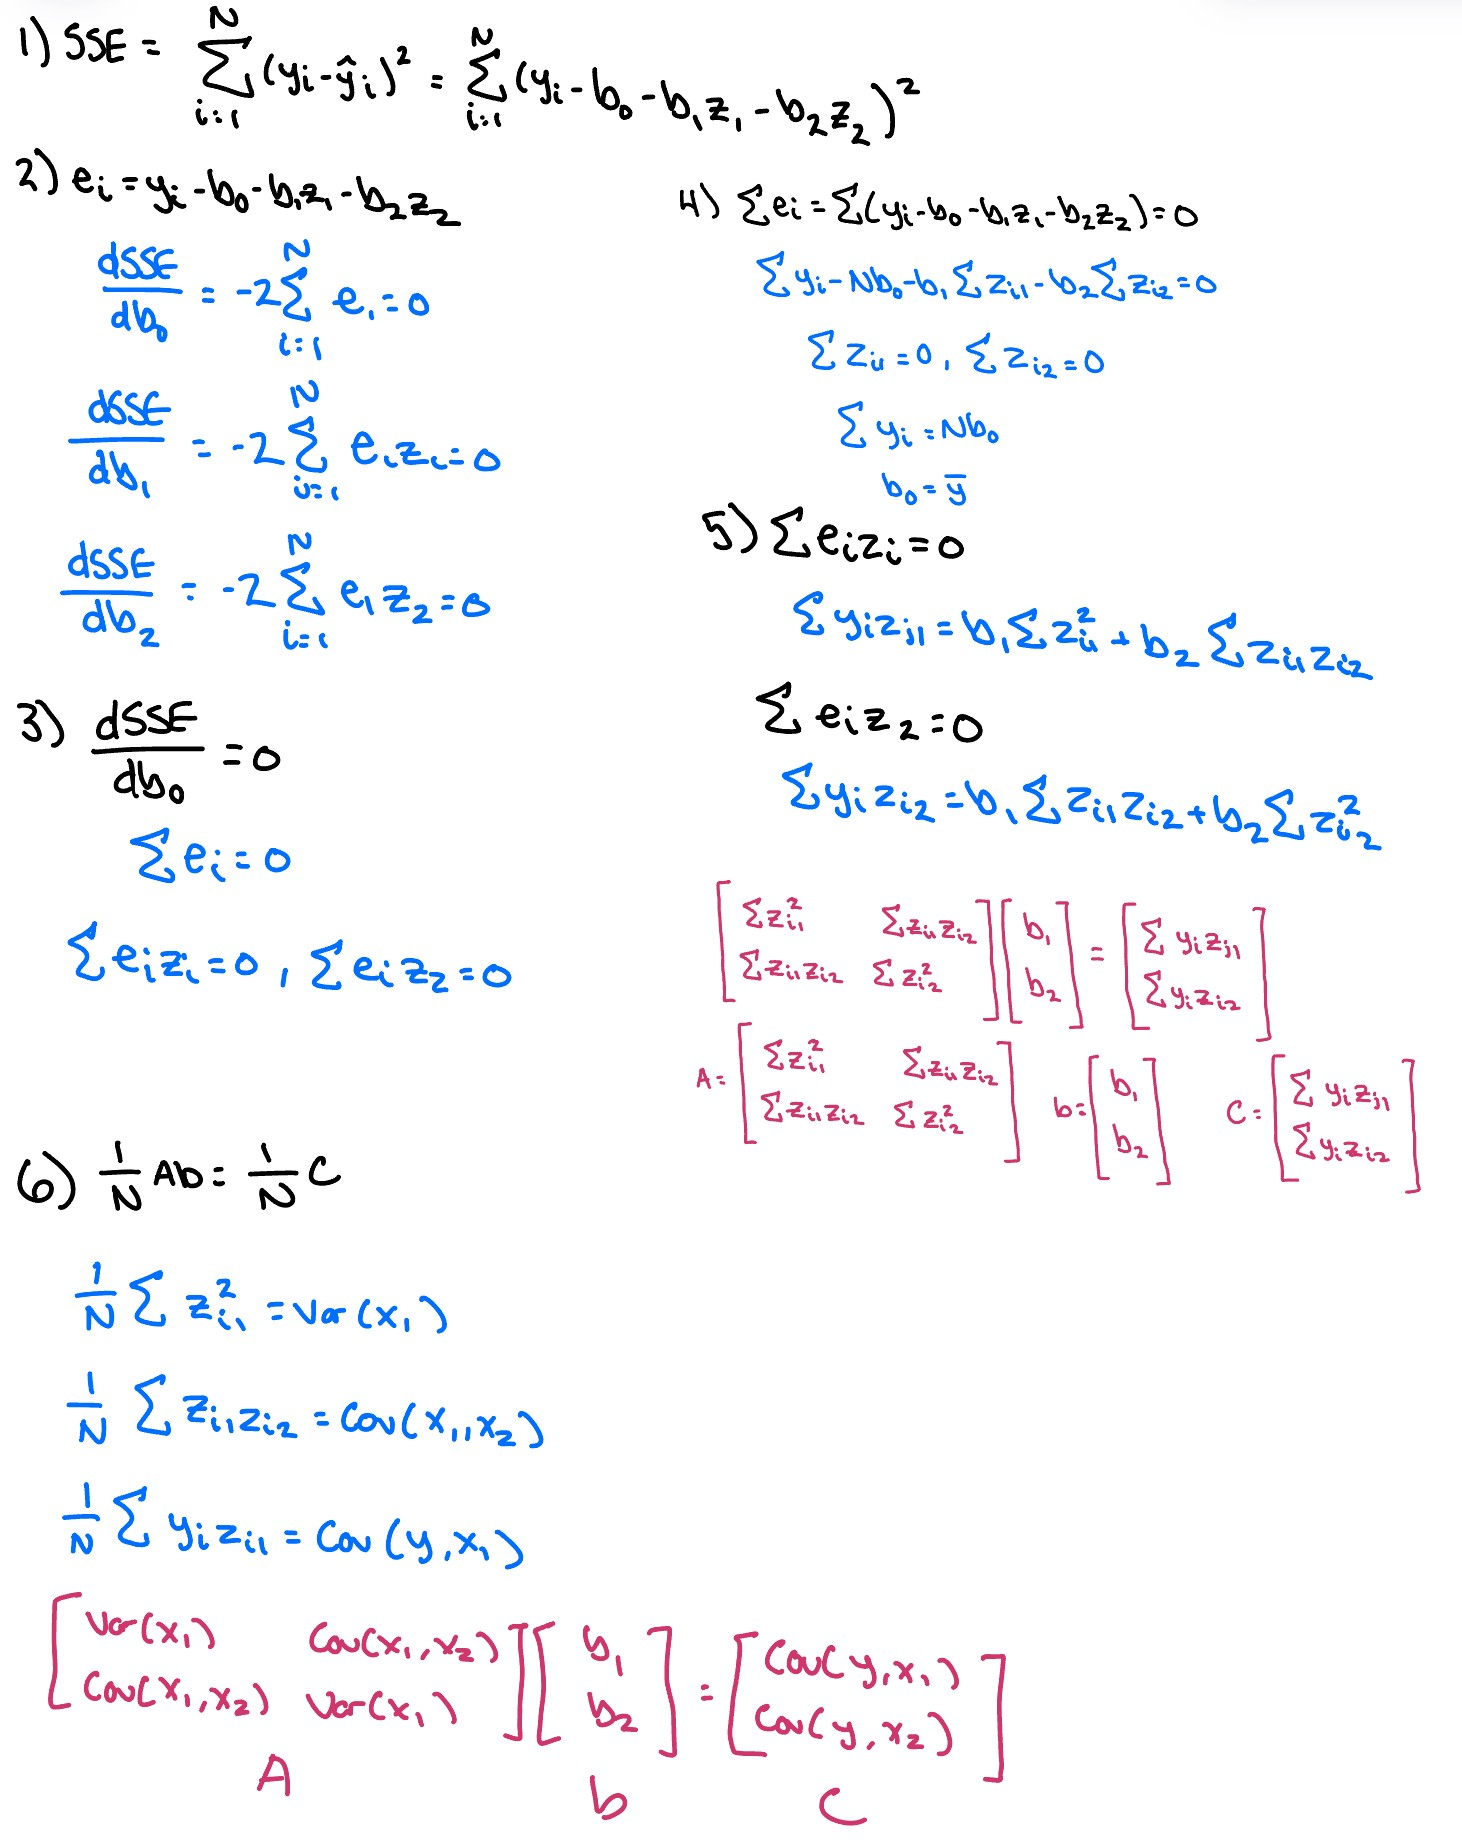

Matrix A is describing how predictors relate to each other and vector C is describing how each predictor relates to the output.
